In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

sns.set_style("whitegrid")
sns.set_context("poster")
warnings.filterwarnings("ignore")

In [2]:
# UCI doğrudan veri bağlantısı
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    "mpg",  # Hedef değişken (Sayısal float)
    "cylinders",  # Sayısal / Ordinal
    "displacement",  # Sayısal (float)
    "horsepower",  # Sayısal (float)
    "weight",  # Sayısal (float)
    "acceleration",  # Sayısal (float)
    "model_year",  # Sayısal (int)
    "origin",  # Kategorik (1: USA, 2: Europe, 3: Japan)
    "car_name",  # Metin
]

# Boşluklarla ayrılmış veriyi okuma ('?' eksik değerleri ele alma)
df = pd.read_csv(
    url,
    names=column_names,
    delim_whitespace=True,
    na_values="?",
    comment="\t",
)

# Gereksiz metin sütununu çıkarma ve eksik satırları temizleme
df = df.drop(columns=["car_name"]).dropna().reset_index(drop=True)

# 'origin' sütununu anlaşılır kategorik isimlerle eşleme
origin_map = {1: "USA", 2: "Europe", 3: "Japan"}
df["origin"] = df["origin"].map(origin_map)

# Örnek türetilmiş değişken ekleme (Not defterindeki df["Age"] = df["Rings"]+1.5 adımına benzer)
df["model_age"] = (
    82 - df["model_year"]
)  # Veri seti 1982 yılına kadar olduğu için araç yaşı

df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,model_age
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,12
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,12


In [3]:
print("Veri Seti Boyutu:", df.shape)
df.info()

Veri Seti Boyutu: (392, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   model_age     392 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 27.7+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
model_year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
model_age,392.0,6.020408,3.683737,0.0,3.000,6.00,9.000,12.0


In [5]:
df["origin"].value_counts()

,count
origin,
USA,245
Japan,79
Europe,68


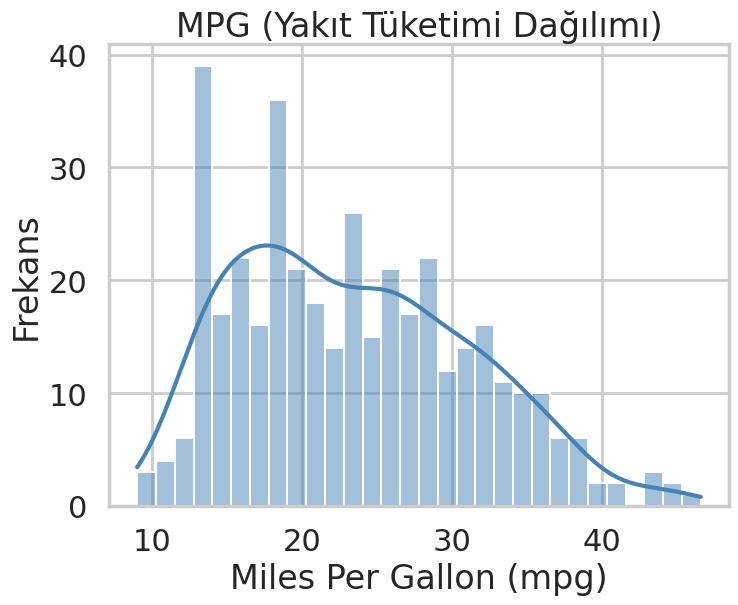

In [6]:
plt.figure(figsize=(8, 6))
sns.histplot(df["mpg"], bins=30, kde=True, color="steelblue")

plt.title("MPG (Yakıt Tüketimi Dağılımı)")
plt.xlabel("Miles Per Gallon (mpg)")
plt.ylabel("Frekans")

plt.show()

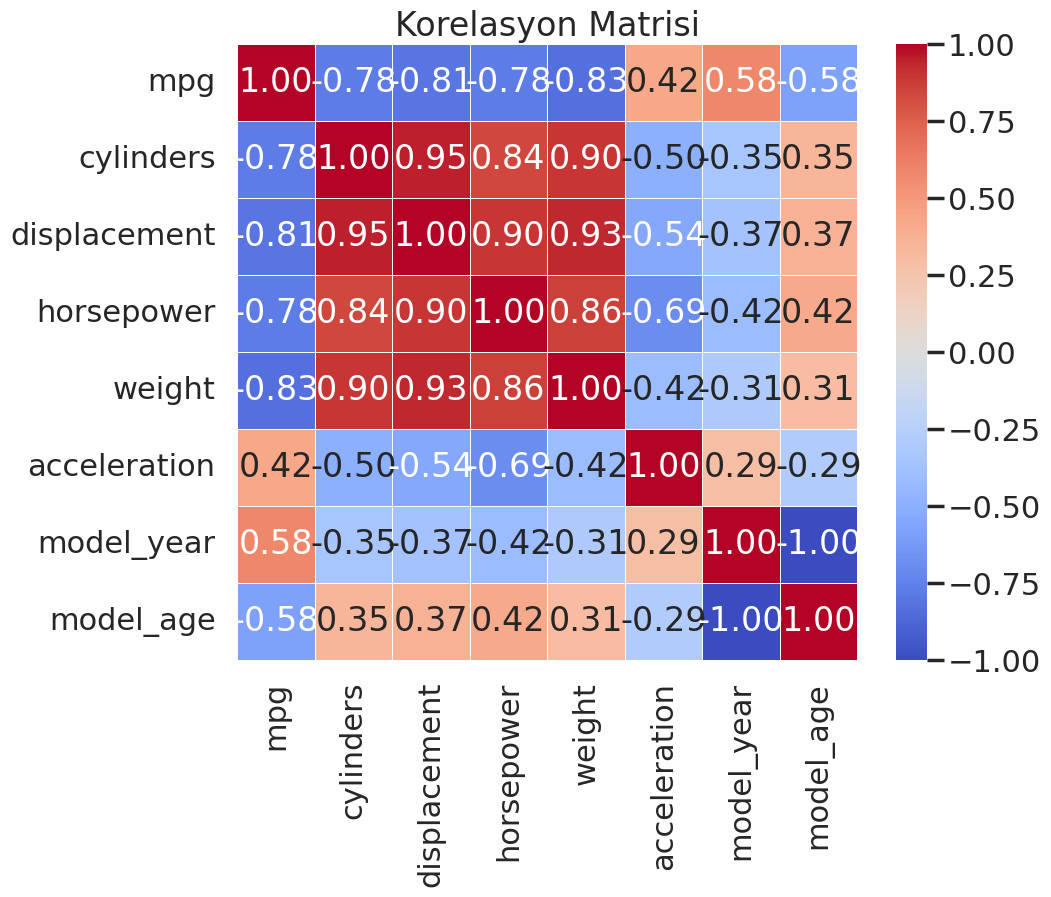

In [7]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelasyon Matrisi")
plt.show()

In [8]:
# Kategorik olan 'origin' sütununu ikili (binary) sütunlara dönüştürme
df_encoded = pd.get_dummies(df, columns=["origin"], drop_first=True)

# Bool değerleri int (0/1) tipine çevirme
dummy_cols = [col for col in df_encoded.columns if "origin_" in col]
for col in dummy_cols:
  df_encoded[col] = df_encoded[col].astype(int)

df_encoded.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,model_age,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,12,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,12,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,12,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,12,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,12,0,1


In [9]:
# Bağımsız değişkenler (X) ve Bağımlı değişken (y)
X = df_encoded.drop(columns=["mpg"])
y = df_encoded["mpg"]

# 1. Train-Test Ayrımı (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Statsmodels ile OLS Özeti (p-değerleri, R-squared ve katsayı analizi)
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

# 3. Özellik Ölçeklendirme (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Scikit-Learn Linear Regression Eğitimi
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Test Verisi Üzerinde Tahmin ve Hata Metrikleri
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("-" * 40)
print(f"Mean Absolute Error (MAE) : {mae:.3f}")
print(f"Mean Squared Error (MSE)  : {mse:.3f}")
print(f"Root Mean Squared Error   : {rmse:.3f}")
print(f"R² Skoru (Başarı Oranı)   : {r2:.3f}")
print("-" * 40)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     183.8
Date:                Tue, 22 Sep 2026   Prob (F-statistic):          1.20e-111
Time:                        10:38:49   Log-Likelihood:                -816.67
No. Observations:                 313   AIC:                             1651.
Df Residuals:                     304   BIC:                             1685.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0048      0.001      4.897   